# 2주차 · 취향이 비슷한 사람끼리 묶는다

지난주에는 가장 많이 팔린 종목 10개를 300명 모두에게 똑같이 보여 주었습니다. 점수는 0.2163이 나왔고,
알고리즘을 하나도 쓰지 않은 것 치고는 나쁘지 않았습니다.

그런데 마지막에 문제를 하나 보았습니다. 원금을 지키는 것이 최우선인 안정형 투자자와 레버리지 상품까지
담는 공격형 투자자에게 우리는 같은 근거로 만든 같은 목록을 내밀었습니다.

오늘은 이 문제를 풉니다. **그 사람이 지금까지 담아 온 것을 보고** 취향을 짐작해서, 사람마다 다른 목록을
만듭니다. 그리고 추천을 채점하는 방법이 하나가 아니라는 것을 알아보고, 세 가지 지표를 직접 계산해 봅니다.

In [1]:
# 준비 — 필요한 도구를 불러옵니다.
# recsys.py 는 모든 주차가 함께 쓰는 도구 상자입니다. 데이터를 읽는 방법, 데이터를 나누는 방법,
# 점수를 재는 방법이 여기에 한 번만 적혀 있습니다.
import sys

sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import recsys

# 맥에서 그래프의 한글이 깨지지 않게 합니다. 윈도우라면 "Malgun Gothic" 으로 바꾸세요.
matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

print("준비 완료")

준비 완료


## 1. 지난주의 문제를 다시 확인한다

먼저 지난주 방식을 그대로 재현해서, 두 사람이 받는 목록이 왜 사실상 같은 것인지 눈으로 봅니다.

In [2]:
items, users, inter = recsys.load()
train, test, cut = recsys.split_by_time(inter)
name_of = items.set_index("item_id")["name"].to_dict()
seen_map = train.groupby("user_id")["item_id"].apply(set).to_dict()

인기순위 = list(train["item_id"].value_counts().index)


def 모두에게_같은_추천(user_id, seen):
    return recsys.take(인기순위, seen)


지난주_점수, _ = recsys.recall_at_k(모두에게_같은_추천, train, test)
print(f"지난주 방식의 점수 Recall@10 = {지난주_점수:.4f}")

지난주 방식의 점수 Recall@10 = 0.2163


## 2. 거래 기록에서 취향을 짐작한다

그 사람이 어떤 사람인지 알아내는 가장 쉬운 방법은 **지금까지 담아 온 것을 보는 것**입니다.
반도체 종목만 담아 온 사람에게는 반도체에서 인기 있는 것을, 채권 상품만 담아 온 사람에게는
채권에서 인기 있는 것을 주면 됩니다.

`users.csv` 에는 투자 성향 라벨이 들어 있지만 **쓰지 않습니다.** 두 가지 이유가 있습니다.
첫째로 이 라벨은 데이터를 만들 때 심어 둔 정답지라서, 그걸 쓰면 답을 보고 푸는 것이 됩니다.
둘째로 실제 서비스에는 그런 라벨이 없는 경우가 많고, 있더라도 행동 기록이 훨씬 정직합니다.
설문에서 안정형이라고 답한 사람이 레버리지 상품을 사는 일은 흔합니다.

In [3]:
# 거래 기록에 종목 정보를 붙입니다.
섹터_of = items.set_index("item_id")["sector"].to_dict()
위험도_of = items.set_index("item_id")["risk_level"].to_dict()

# 사람마다 가장 많이 담은 섹터를 찾습니다. value_counts() 결과의 첫 줄을 가져오는 것이 전부입니다.
주력섹터 = (
    train.assign(s=train["item_id"].map(섹터_of))
    .groupby("user_id")["s"]
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

# 그 사람이 담은 종목들의 평균 위험도를 구해 반올림합니다.
평균위험도 = (
    train.assign(r=train["item_id"].map(위험도_of))
    .groupby("user_id")["r"]
    .mean()
    .round(0)
    .astype(int)
    .to_dict()
)

# 두 값을 합치면 무리 이름이 만들어집니다.
무리 = {u: f"{주력섹터[u]}|{평균위험도[u]}" for u in 주력섹터}

print(f"투자자 {len(무리)}명이 {len(set(무리.values()))}개 무리로 나뉘었습니다.\n")
for u in list(무리)[:5]:
    print(f"  {u}  →  {무리[u]}")

투자자 285명이 15개 무리로 나뉘었습니다.

  U0001  →  Financials|3
  U0002  →  Semiconductor|4
  U0003  →  Leveraged|4
  U0004  →  Dividend|3
  U0005  →  Index|4


In [4]:
# 무리별 인원을 세어 봅니다. 사람이 몰린 무리와 한두 명뿐인 무리가 함께 나옵니다.
무리표 = pd.Series(무리).value_counts().rename("인원").to_frame()
무리표.index.name = "무리 (주력섹터|평균위험도)"
무리표

,인원
무리 (주력섹터|평균위험도),
Index|3,89
Index|4,73
Semiconductor|4,28
Leveraged|4,24
Semiconductor|3,22
Financials|3,16
Battery|4,14
Dividend|3,6
Index|2,4


## 3. 무리별 인기 목록으로 추천한다

이제 무리마다 인기 순위표를 따로 만들고, 각자 자기 무리의 순위표에서 10개를 받습니다.
모델을 학습시키는 것이 아니라 사람이 정한 규칙만으로 만드는 방식이라 **규칙 기반 추천**이라고 부릅니다.

In [5]:
무리별_순위표 = {
    g: list(v["item_id"].value_counts().index)
    for g, v in train.assign(g=train["user_id"].map(무리)).groupby("g")
}


def 무리별_추천(user_id, seen):
    """그 사람이 속한 무리의 순위표에서 아직 안 담은 것 10개를 준다."""
    순위표 = 무리별_순위표.get(무리.get(user_id), 인기순위)
    return recsys.take(순위표, seen)


이번주_점수, n_eval = recsys.recall_at_k(무리별_추천, train, test)
print(f"지난주 (모두에게 같은 목록)  Recall@10 = {지난주_점수:.4f}")
print(f"이번주 (무리별 목록)        Recall@10 = {이번주_점수:.4f}")
print(f"\n{(이번주_점수 - 지난주_점수) / 지난주_점수:+.1%} 올랐습니다.  (채점 대상 {n_eval}명)")

지난주 (모두에게 같은 목록)  Recall@10 = 0.2163
이번주 (무리별 목록)        Recall@10 = 0.2684

+24.1% 올랐습니다.  (채점 대상 266명)


지난주에 비교했던 두 사람을 다시 불러옵니다. 이번에는 목록이 정말로 달라졌는지 봅니다.

In [6]:
채점대상 = set(test["user_id"])
안정형 = [u for u in users[users["persona"] == "Conservative"]["user_id"] if u in 채점대상][0]
공격형 = [u for u in users[users["persona"] == "Aggressive"]["user_id"] if u in 채점대상][0]

print(f"{안정형} 이 속한 무리: {무리.get(안정형)}")
print(f"{공격형} 이 속한 무리: {무리.get(공격형)}\n")

비교 = pd.DataFrame({
    f"{안정형} (Conservative)": [name_of[i] for i in 무리별_추천(안정형, seen_map.get(안정형, set()))],
    f"{공격형} (Aggressive)": [name_of[i] for i in 무리별_추천(공격형, seen_map.get(공격형, set()))],
})
비교.index = range(1, 11)
비교

U0001 이 속한 무리: Financials|3
U0003 이 속한 무리: Leveraged|4



,U0001 (Conservative),U0003 (Aggressive)
1,TIGER US Dividend Dow Jones,TIGER US Nasdaq 100 Leverage
2,iShares 20+ Year Treasury Bond ETF,ProShares UltraPro Short QQQ
3,TIGER Bank High Dividend TOP10,iShares Global Clean Energy ETF
4,Shinhan Financial Group,Alteogen
5,ACE US Dividend Dow Jones,LG Energy Solution
6,ProShares UltraPro QQQ,Advanced Micro Devices
7,Vanguard Total Bond Market ETF,TIGER REIT Real Estate Infra
8,Vanguard High Dividend Yield ETF,Vanguard FTSE Developed Markets ETF
9,KODEX US Dividend Dow Jones,KODEX Korea Treasury Bond 30Y
10,Vanguard FTSE Developed Markets ETF,TIGER Battery Theme


## 4. 추천을 채점하는 세 가지 방법

지금까지 Recall@10 하나만 써 왔지만, 추천을 채점하는 방법은 여러 가지입니다. 대표적인 세 가지를
직접 계산해 보면서 무엇이 다른지 확인합니다.

- **Precision@10** — 내가 추천한 10개 중 몇 개가 맞았나. 추천 목록의 정확도를 봅니다.
- **Recall@10** — 그 사람이 실제로 담은 것 중 몇 개를 맞혔나. 놓친 것이 없는지를 봅니다.
- **NDCG@10** — 맞힌 것이 목록의 몇 번째에 있었는지까지 따집니다. 같은 두 개를 맞혀도
  1·2등에서 맞힌 쪽이 9·10등에서 맞힌 쪽보다 점수가 높습니다.

Precision과 Recall은 **분자가 같고 분모만 다릅니다.** 분자는 둘 다 "맞힌 개수"이고,
추천 개수로 나누면 Precision, 실제 담은 개수로 나누면 Recall입니다.

In [7]:
import numpy as np


def 세_지표(추천함수, train, test, k=10):
    """Precision@k · Recall@k · NDCG@k 를 한 번에 계산한다."""
    seen_map = train.groupby("user_id")["item_id"].apply(set).to_dict()

    # NDCG 에서 쓸 자리별 가중치. 아래로 갈수록 작아집니다.
    할인 = 1 / np.log2(np.arange(2, k + 2))

    p, r, n = [], [], []
    for uid, grp in test.groupby("user_id"):
        seen = seen_map.get(uid, set())
        정답 = set(grp["item_id"]) - seen
        if not 정답:
            continue
        추천 = 추천함수(uid, seen)[:k]
        맞힌개수 = len(정답 & set(추천))

        p.append(맞힌개수 / k)
        r.append(맞힌개수 / len(정답))

        # 맞힌 자리의 가중치를 더하고, 가능한 최댓값으로 나눕니다.
        얻은점수 = sum(할인[i] for i, item in enumerate(추천) if item in 정답)
        최대점수 = 할인[: min(len(정답), k)].sum()
        n.append(얻은점수 / 최대점수)

    return float(np.mean(p)), float(np.mean(r)), float(np.mean(n))


prec, rec, ndcg = 세_지표(무리별_추천, train, test)
print(f"Precision@10 = {prec:.4f}")
print(f"Recall@10    = {rec:.4f}")
print(f"NDCG@10      = {ndcg:.4f}")

Precision@10 = 0.0951
Recall@10    = 0.2684
NDCG@10      = 0.1923


직접 짠 Recall 이 도구 상자의 `recsys.recall_at_k` 와 같은 값이 나오는지 맞춰 봅니다.
값이 다르다면 대개 **이미 담은 종목을 정답에서 빼지 않은 것**이 원인입니다.

In [8]:
assert abs(rec - 이번주_점수) < 1e-9, f"직접 계산 {rec} 과 도구 상자 {이번주_점수} 가 다릅니다"
print(f"직접 계산한 Recall {rec:.4f} 이 도구 상자 값 {이번주_점수:.4f} 과 같습니다.")

직접 계산한 Recall 0.2684 이 도구 상자 값 0.2684 과 같습니다.


같은 방식으로 지난주 추천과 이번주 추천을 세 지표 모두로 채점해서 나란히 놓아 봅니다.

In [9]:
결과 = pd.DataFrame(
    [세_지표(모두에게_같은_추천, train, test), 세_지표(무리별_추천, train, test)],
    columns=["Precision@10", "Recall@10", "NDCG@10"],
    index=["1주차 · 모두에게 같은 목록", "2주차 · 무리별 목록"],
).round(4)
결과

,Precision@10,Recall@10,NDCG@10
1주차 · 모두에게 같은 목록,0.0793,0.2163,0.1711
2주차 · 무리별 목록,0.0951,0.2684,0.1923


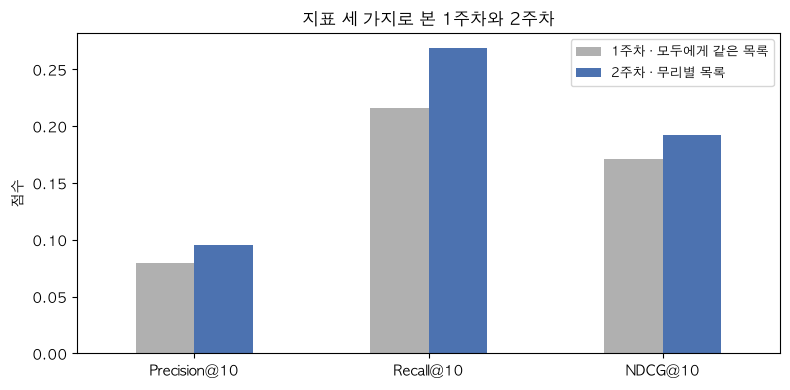

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
결과.T.plot(kind="bar", ax=ax, color=["#B0B0B0", "#4C72B0"], rot=0)
ax.set_ylabel("점수")
ax.set_title("지표 세 가지로 본 1주차와 2주차")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

세 지표 모두에서 2주차가 나은 것을 볼 수 있습니다. 어느 지표를 쓸지는 서비스가 무엇을 중요하게
여기는지에 달렸습니다. 화면에 열 칸이 있고 그 안에 담을 만한 것이 최대한 들어가길 바란다면
Recall 이 맞습니다. 우리 수업이 Recall@10 을 고른 이유가 그것입니다.

In [11]:
recsys.record(2, "취향이 비슷한 무리끼리", 이번주_점수,
              note="거래 기록으로 주력 섹터와 평균 위험도를 짐작해 15개 무리로 나눴다")

레벨 2 · 취향이 비슷한 무리끼리 · Recall@10 = 0.2684


{'level': 2,
 'name': '취향이 비슷한 무리끼리',
 'recall_at_10': 0.2684,
 'note': '거래 기록으로 주력 섹터와 평균 위험도를 짐작해 15개 무리로 나눴다'}

## 오늘의 마무리

거래 기록만 보고 사람을 무리로 나누었더니 점수가 올랐습니다. 성향 라벨 같은 것을 따로 받지 않고도
"이 사람이 무엇을 좋아하는지"를 어느 정도 짐작할 수 있다는 뜻입니다.

그런데 아직 한계가 남아 있습니다. **같은 무리에 속한 사람들은 여전히 똑같은 목록을 받습니다.**
반도체를 주로 담는 사람이 스무 명이라면 그 스무 명은 완전히 같은 추천을 받습니다. 사람마다 다른
추천이 되긴 했지만, 무리 단위로만 달라진 것입니다.

그리고 더 신경 쓰이는 것이 하나 있습니다. 우리가 지금까지 재 온 점수가 **정말 믿을 만한 숫자인지**
아직 확인해 보지 않았습니다. 다음 주에는 모델을 하나도 바꾸지 않고 채점 방법만 다시 들여다봅니다.
그런데 점수가 떨어집니다.